In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA_DIR = Path('../data')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# Load clean data
df = pd.read_csv(DATA_DIR / 'olist_clean.csv', parse_dates=[
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
])

print(f"Loaded: {df.shape}")

Loaded: (110645, 22)


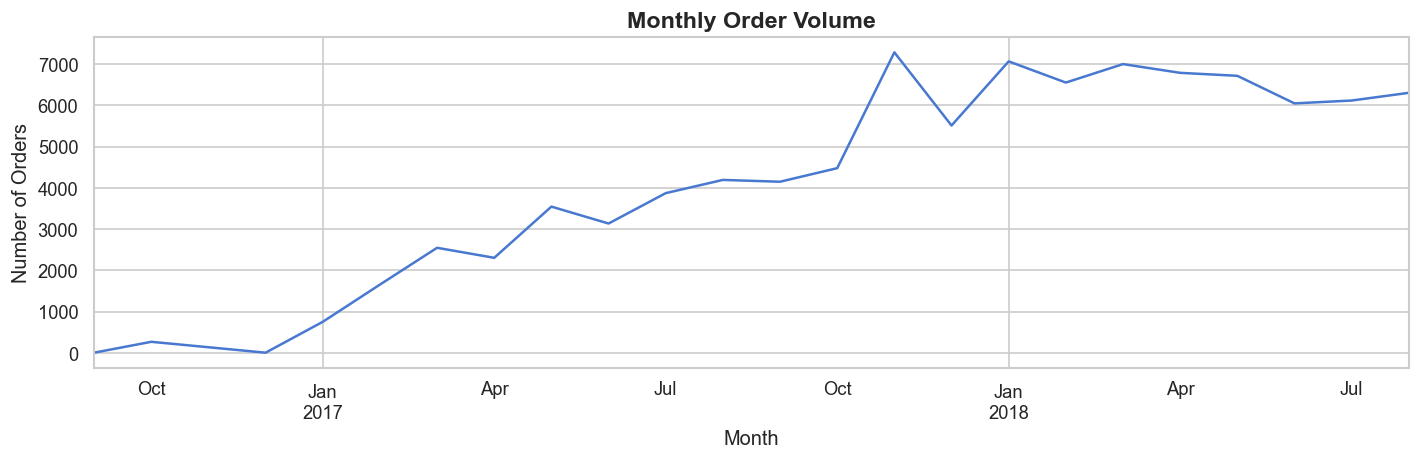

Peak month: 2017-11 (7,288 orders)
Total months: 23


In [2]:
# Order volume over time
df['month'] = df['order_purchase_timestamp'].dt.to_period('M')
monthly_orders = df.groupby('month')['order_id'].nunique()

fig, ax = plt.subplots(figsize=(12, 4))
monthly_orders.plot(ax=ax)
ax.set_title('Monthly Order Volume', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Orders')
plt.tight_layout()
plt.savefig('../visuals/01_monthly_order_volume.png', dpi=120)
plt.show()

print(f"Peak month: {monthly_orders.idxmax()} ({monthly_orders.max():,} orders)")
print(f"Total months: {len(monthly_orders)}")

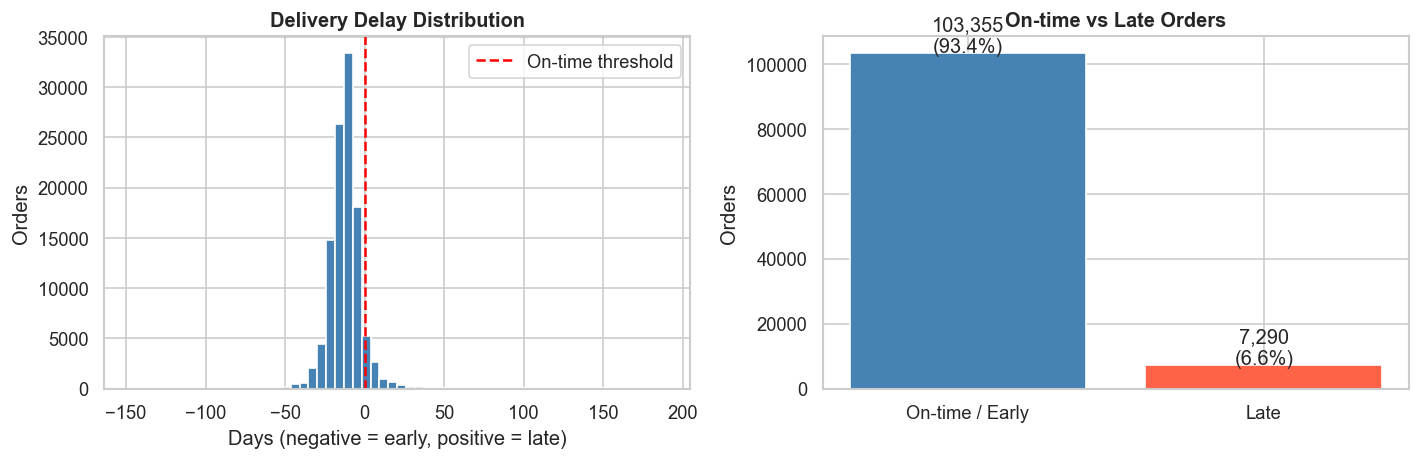

In [3]:
# DELIVERY PERFORMANCE OVERVIEW
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Delay distribution
axes[0].hist(df['delay_days'].dropna(), bins=60, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', label='On-time threshold')
axes[0].set_title('Delivery Delay Distribution', fontweight='bold')
axes[0].set_xlabel('Days (negative = early, positive = late)')
axes[0].set_ylabel('Orders')
axes[0].legend()

# Late vs on-time
late_counts = df['is_late'].value_counts()
axes[1].bar(['On-time / Early', 'Late'], late_counts.values, color=['steelblue', 'tomato'])
axes[1].set_title('On-time vs Late Orders', fontweight='bold')
axes[1].set_ylabel('Orders')
for i, v in enumerate(late_counts.values):
    axes[1].text(i, v + 200, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center')

plt.tight_layout()
plt.savefig('../visuals/02_delivery_performance.png', dpi=120)
plt.show()

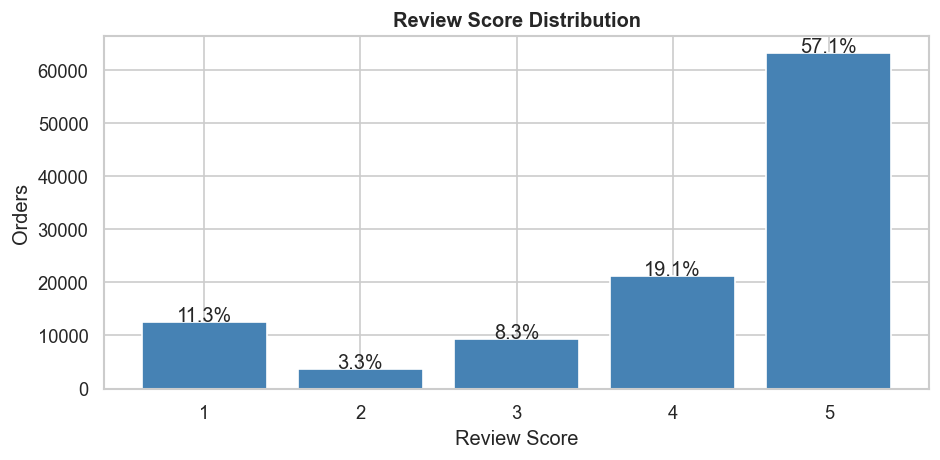

Mean review score: 4.08
% 5-star reviews: 57.5%
% 1-star reviews: 11.4%


In [4]:
# REVIEW SCORE DISTRIBUTION
fig, ax = plt.subplots(figsize=(8, 4))
review_counts = df['review_score'].value_counts().sort_index()
ax.bar(review_counts.index, review_counts.values, color='steelblue', edgecolor='white')
ax.set_title('Review Score Distribution', fontweight='bold')
ax.set_xlabel('Review Score')
ax.set_ylabel('Orders')
for i, (score, count) in enumerate(review_counts.items()):
    ax.text(score, count + 200, f'{count/len(df)*100:.1f}%', ha='center')

plt.tight_layout()
plt.savefig('../visuals/03_review_scores.png', dpi=120)
plt.show()

print(f"Mean review score: {df['review_score'].mean():.2f}")
print(f"% 5-star reviews: {(df['review_score']==5).sum()/df['review_score'].notna().sum()*100:.1f}%")
print(f"% 1-star reviews: {(df['review_score']==1).sum()/df['review_score'].notna().sum()*100:.1f}%")

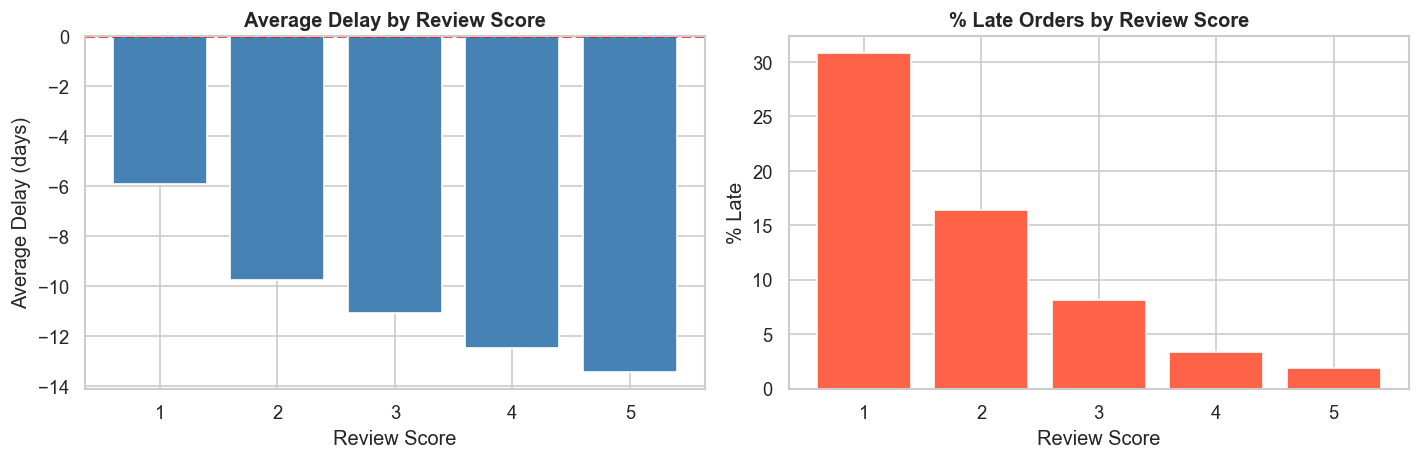

review_score
1.00    -5.93
2.00    -9.73
3.00   -11.08
4.00   -12.47
5.00   -13.42
Name: delay_days, dtype: float64

review_score
1.00   30.82
2.00   16.38
3.00    8.16
4.00    3.34
5.00    1.86
Name: is_late, dtype: float64


In [5]:
# REVIEW SCORE VS DELIVERY PERFORMANCE
review_delay = df.groupby('review_score')['delay_days'].mean()
review_late = df.groupby('review_score')['is_late'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(review_delay.index, review_delay.values, color='steelblue', edgecolor='white')
axes[0].set_title('Average Delay by Review Score', fontweight='bold')
axes[0].set_xlabel('Review Score')
axes[0].set_ylabel('Average Delay (days)')
axes[0].axhline(0, color='red', linestyle='--')

axes[1].bar(review_late.index, review_late.values, color='tomato', edgecolor='white')
axes[1].set_title('% Late Orders by Review Score', fontweight='bold')
axes[1].set_xlabel('Review Score')
axes[1].set_ylabel('% Late')

plt.tight_layout()
plt.savefig('../visuals/04_review_vs_delivery.png', dpi=120)
plt.show()

print(review_delay)
print()
print(review_late)

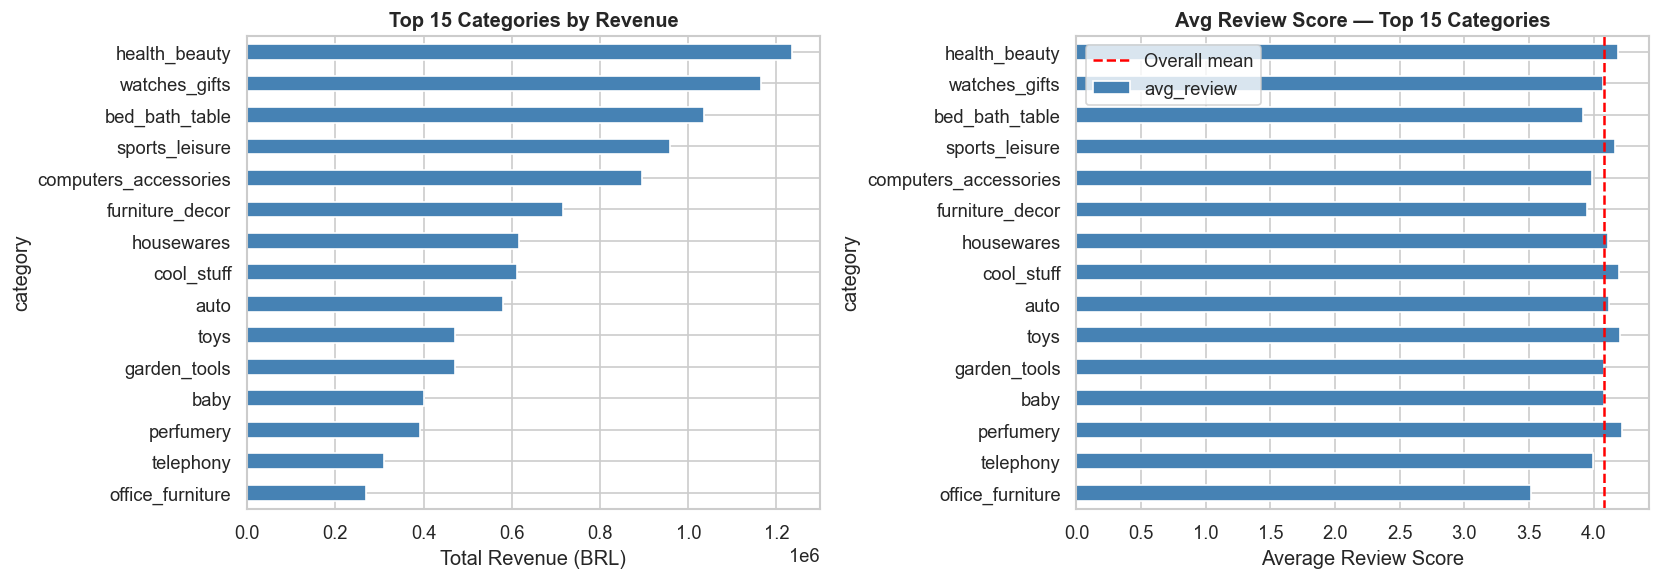

                       orders    revenue  avg_price  avg_review
category                                                       
health_beauty            8631 1235950.19     130.06        4.19
watches_gifts            5483 1164899.36     198.89        4.07
bed_bath_table           9253 1035718.34      93.42        3.92
sports_leisure           7519  958455.14     113.11        4.17
computers_accessories    6519  895251.65     116.31        3.98
furniture_decor          6296  716387.02      87.11        3.95
housewares               5734  616722.60      90.61        4.11
cool_stuff               3556  611846.98     164.30        4.20
auto                     3793  578812.74     139.84        4.12
toys                     3797  471473.94     116.96        4.21


In [6]:
# TOP CATEGORIES BY VOLUME & REVENUE
cat_stats = df.groupby('category').agg(
    orders=('order_id', 'nunique'),
    revenue=('price', 'sum'),
    avg_price=('price', 'mean'),
    avg_review=('review_score', 'mean')
).sort_values('revenue', ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cat_stats['revenue'].plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 15 Categories by Revenue', fontweight='bold')
axes[0].set_xlabel('Total Revenue (BRL)')
axes[0].invert_yaxis()

cat_stats['avg_review'].plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Avg Review Score — Top 15 Categories', fontweight='bold')
axes[1].set_xlabel('Average Review Score')
axes[1].axvline(df['review_score'].mean(), color='red', linestyle='--', label='Overall mean')
axes[1].invert_yaxis()
axes[1].legend()

plt.tight_layout()
plt.savefig('../visuals/05_category_performance.png', dpi=120)
plt.show()

print(cat_stats[['orders', 'revenue', 'avg_price', 'avg_review']].head(10))

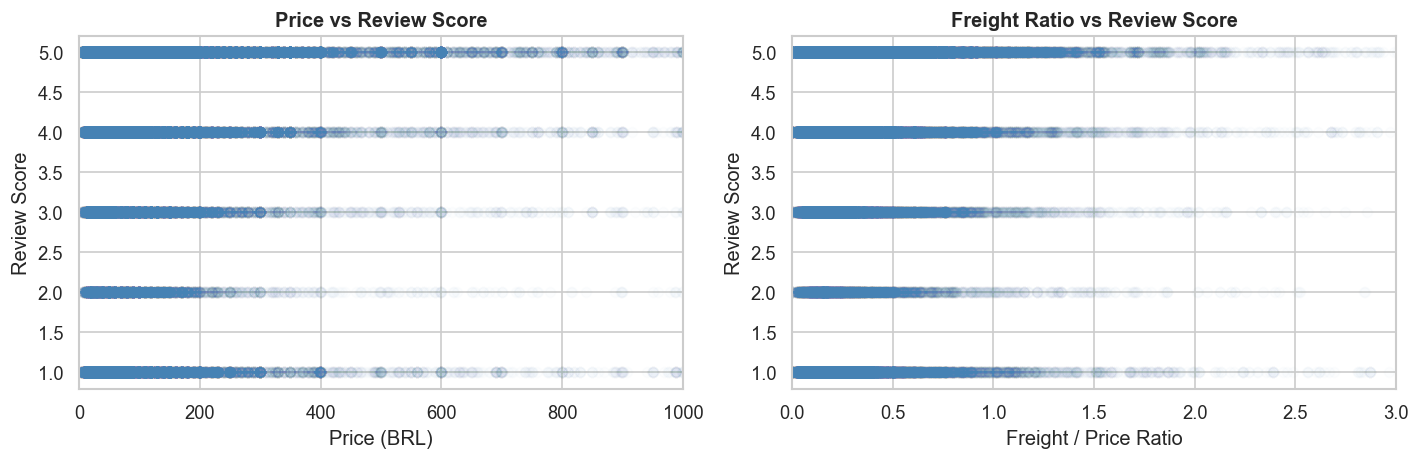

Avg freight ratio: 0.23
Correlation — price vs review: 0.003
Correlation — freight ratio vs review: -0.040


In [9]:
# FREIGHT VS PRICE ANALYSIS
df['freight_ratio'] = df['freight_value'] / df['price']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(df['price'], df['review_score'], alpha=0.01, color='steelblue')
axes[0].set_title('Price vs Review Score', fontweight='bold')
axes[0].set_xlabel('Price (BRL)')
axes[0].set_ylabel('Review Score')
axes[0].set_xlim(0, 1000)

axes[1].scatter(df['freight_ratio'], df['review_score'], alpha=0.01, color='steelblue')
axes[1].set_title('Freight Ratio vs Review Score', fontweight='bold')
axes[1].set_xlabel('Freight / Price Ratio')
axes[1].set_ylabel('Review Score')
axes[1].set_xlim(0, 3)

plt.tight_layout()
plt.savefig('../visuals/06_price_freight_review.png', dpi=120)
plt.show()

print(f"Avg freight ratio: {df['freight_ratio'].median():.2f}")
print(f"Correlation — price vs review: {df['price'].corr(df['review_score']):.3f}")
print(f"Correlation — freight ratio vs review: {df['freight_ratio'].corr(df['review_score']):.3f}")

In [10]:
# SELLER STATE PERFORMANCE
seller_state_stats = df.groupby('seller_state').agg(
    orders=('order_id', 'nunique'),
    avg_delay=('delay_days', 'mean'),
    late_pct=('is_late', 'mean'),
    avg_review=('review_score', 'mean')
).sort_values('orders', ascending=False).head(10)

print(seller_state_stats.round(2))

              orders  avg_delay  late_pct  avg_review
seller_state                                         
SP             68526     -11.30      0.07        4.05
MG              7712     -13.49      0.05        4.16
PR              7498     -14.23      0.05        4.13
RJ              4222     -12.48      0.07        4.17
SC              3595     -14.20      0.05        4.13
RS              1958     -16.30      0.03        4.25
DF               807     -13.19      0.06        4.07
BA               549     -12.80      0.04        4.16
GO               450     -14.35      0.03        4.31
PE               403     -16.24      0.03        4.15


In [11]:
# NOTEBOOK 02 SUMMARY
print("""
Notebook 02 — Exploratory Analysis 
============================================
Key Findings:
1. 93% of orders arrive early — Olist deliberately pads estimates
2. Late orders have 30.8% rate for 1-star vs 1.86% for 5-star reviews
3. Even early orders receive 1-star reviews — delivery alone doesn't 
   explain dissatisfaction
4. Health & beauty leads revenue; watches & gifts highest avg price
5. Price has almost no correlation with satisfaction (r=0.003)
6. High freight-to-price ratio slightly reduces satisfaction (r=-0.040)
7. SP dominates volume; smaller states show better delivery performance

Ready for Notebook 03: Predicting Customer Satisfaction
""")


Notebook 02 — Exploratory Analysis 
Key Findings:
1. 93% of orders arrive early — Olist deliberately pads estimates
2. Late orders have 30.8% rate for 1-star vs 1.86% for 5-star reviews
3. Even early orders receive 1-star reviews — delivery alone doesn't 
   explain dissatisfaction
4. Health & beauty leads revenue; watches & gifts highest avg price
5. Price has almost no correlation with satisfaction (r=0.003)
6. High freight-to-price ratio slightly reduces satisfaction (r=-0.040)
7. SP dominates volume; smaller states show better delivery performance

Ready for Notebook 03: Predicting Customer Satisfaction

